# Bike Sharing Rental Prediction

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

## 1. Load & Clean Data

In [2]:
# Load
df = pd.read_csv('Dataset.csv')

# Clean
df.replace('?', np.nan, inplace=True)
cat_cols = df.select_dtypes(include=['object','category']).columns
for col in cat_cols:
    df[col] = df[col].str.strip().str.lower()

df['season'] = df['season'].replace('springer', 'spring')
df['dteday'] = pd.to_datetime(df['dteday'], dayfirst=True)

# Convert types
num_cols = ['temp','atemp','hum','windspeed','casual','registered','cnt']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna().drop('instant', axis=1)
print(f"Cleaned dataset: {df.shape}")

Cleaned dataset: (17339, 16)


## 2. Quick EDA

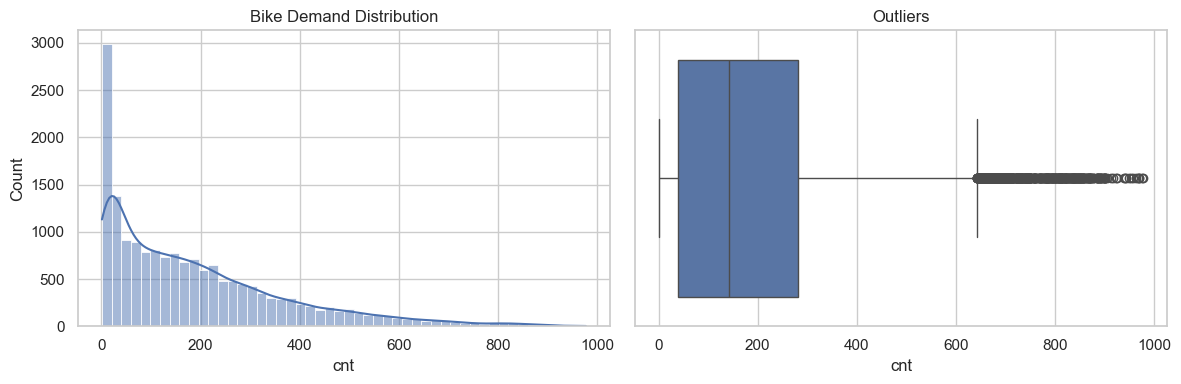

In [3]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['cnt'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Bike Demand Distribution')
sns.boxplot(x=df['cnt'], ax=axes[1])
axes[1].set_title('Outliers')
plt.tight_layout()
plt.show()

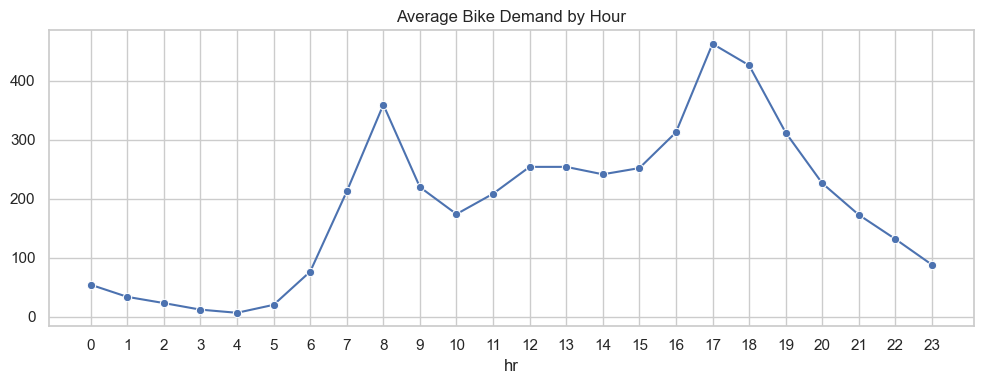

In [4]:
# Hourly pattern
hourly_avg = df.groupby('hr')['cnt'].mean()
plt.figure(figsize=(10, 4))
sns.lineplot(x=hourly_avg.index, y=hourly_avg.values, marker='o')
plt.title('Average Bike Demand by Hour')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

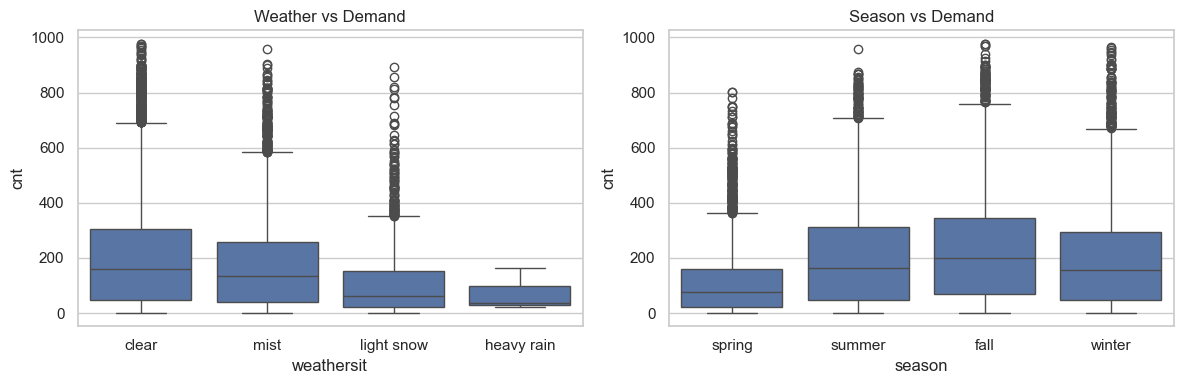

In [5]:
# Weather vs demand
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x='weathersit', y='cnt', data=df, ax=axes[0])
axes[0].set_title('Weather vs Demand')
sns.boxplot(x='season', y='cnt', data=df, ax=axes[1])
axes[1].set_title('Season vs Demand')
plt.tight_layout()
plt.show()

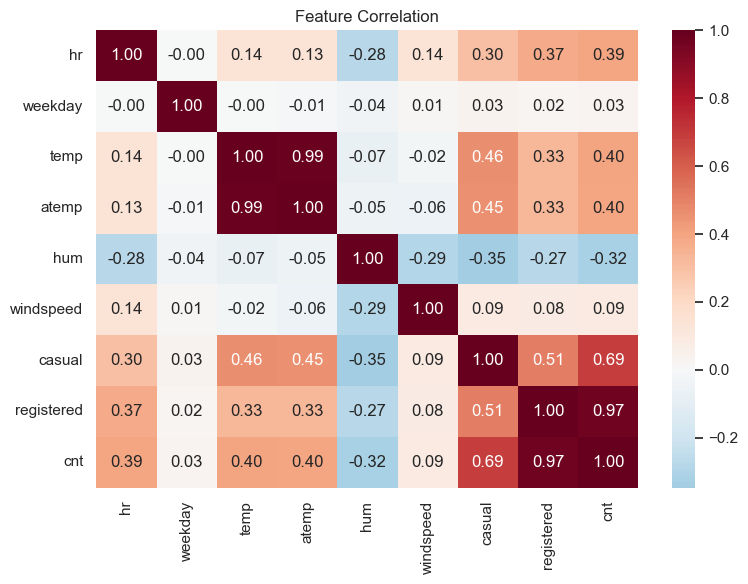

In [6]:
# Correlation
num_df = df.select_dtypes(include=['int64','float64'])
plt.figure(figsize=(8, 6))
sns.heatmap(num_df.corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Feature Correlation')
plt.tight_layout()
plt.show()

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, ExtraTreesRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time

# Define 6 best performing models
models = {
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=10),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Extra Trees': ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostRegressor(n_estimators=100, random_state=42),
    'KNN': KNeighborsRegressor(n_neighbors=5)
}

print(f"Training {len(models)} models...")

In [7]:
# Feature engineering
df['time_of_day'] = pd.cut(df['hr'], bins=[-1, 6, 12, 18, 24], labels=['Night','Morning','Afternoon','Evening'])
df['is_weekend'] = df['weekday'].isin([0, 6]).astype(int)
df['temp_diff'] = df['atemp'] - df['temp']

# Encode
df_encoded = pd.get_dummies(df, drop_first=True)

# Remove leakage columns
leakage_cols = ['casual','registered','dteday','temp_diff']
drop_cols = [c for c in leakage_cols if c in df_encoded.columns]
model_df = df_encoded.drop(columns=drop_cols)

X = model_df.drop(columns=['cnt'])
y = model_df['cnt']
print(f"Features: {X.shape[1]}")

Features: 30


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

## 4. Model Building & Comparison

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, ExtraTreesRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time

# Define 6 best performing models
models = {
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=10),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Extra Trees': ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostRegressor(n_estimators=100, random_state=42),
    'KNN': KNeighborsRegressor(n_neighbors=5)
}

print(f"Training {len(models)} models...")

Training 11 models...


In [ ]:
# Train and evaluate all models
results = []

for name, model in models.items():
    start_time = time.time()
    
    # KNN needs scaled data, tree-based models don't
    if name == 'KNN':
        model.fit(X_train_sc, y_train)
        y_pred = model.predict(X_test_sc)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    train_time = time.time() - start_time
    
    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'Train Time (s)': train_time
    })
    print(f"{name}: RMSE={rmse:.2f}, R2={r2:.4f}")

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('R2', ascending=False)

Linear Regression: RMSE=122.02, R2=0.5497
Ridge: RMSE=122.02, R2=0.5497
Lasso: RMSE=122.46, R2=0.5464
ElasticNet: RMSE=129.27, R2=0.4945
Decision Tree: RMSE=62.07, R2=0.8835
Random Forest: RMSE=41.91, R2=0.9469
Extra Trees: RMSE=40.34, R2=0.9508
Gradient Boosting: RMSE=69.75, R2=0.8529
AdaBoost: RMSE=106.27, R2=0.6584
KNN: RMSE=103.34, R2=0.6770
SVR: RMSE=141.05, R2=0.3982


In [11]:
# Display results
print("\n" + "="*70)
print("MODEL COMPARISON RESULTS")
print("="*70)
display(results_df.round(4))


MODEL COMPARISON RESULTS


,Model,MAE,RMSE,R2,Train Time (s)
6,Extra Trees,25.1693,40.3432,0.9508,0.6694
5,Random Forest,25.5940,41.9123,0.9469,0.7777
4,Decision Tree,38.1237,62.0650,0.8835,0.0337
7,Gradient Boosting,48.2559,69.7481,0.8529,1.0416
9,KNN,69.9115,103.3399,0.6770,2.2614
8,AdaBoost,86.4731,106.2717,0.6584,0.6169
0,Linear Regression,93.0281,122.0155,0.5497,0.0911
1,Ridge,93.0302,122.0161,0.5497,0.0045
2,Lasso,93.2550,122.4569,0.5464,0.4038
3,ElasticNet,95.9000,129.2722,0.4945,0.0325


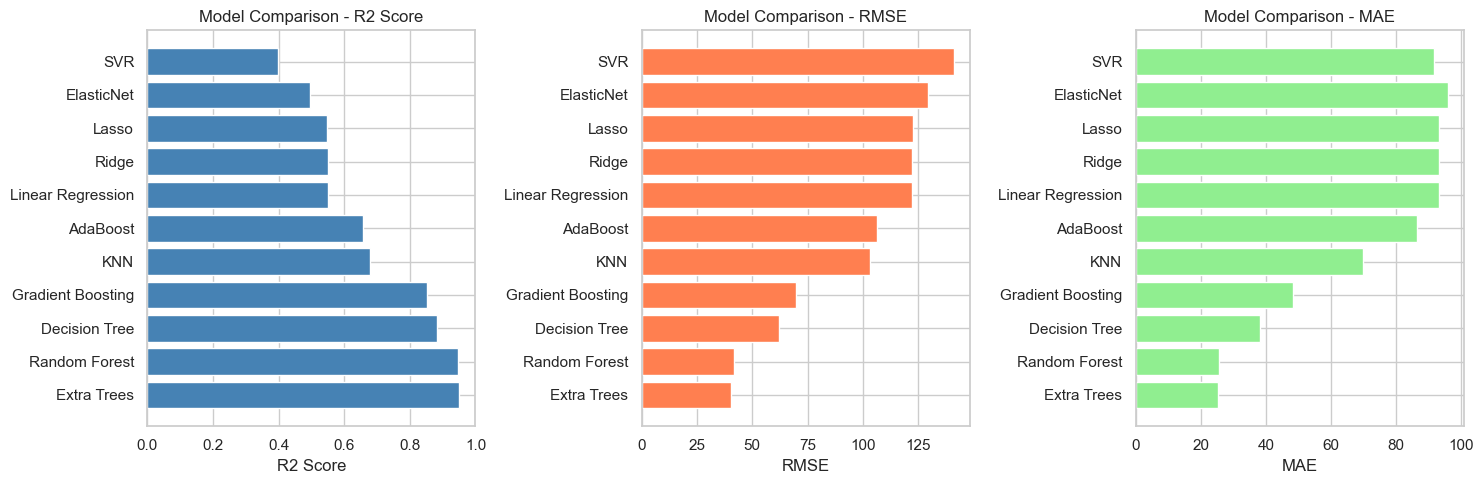

In [12]:
# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# R2 Score
axes[0].barh(results_df['Model'], results_df['R2'], color='steelblue')
axes[0].set_xlabel('R2 Score')
axes[0].set_title('Model Comparison - R2 Score')
axes[0].set_xlim(0, 1)

# RMSE
axes[1].barh(results_df['Model'], results_df['RMSE'], color='coral')
axes[1].set_xlabel('RMSE')
axes[1].set_title('Model Comparison - RMSE')

# MAE
axes[2].barh(results_df['Model'], results_df['MAE'], color='lightgreen')
axes[2].set_xlabel('MAE')
axes[2].set_title('Model Comparison - MAE')

plt.tight_layout()
plt.show()

## 5. Best Model Analysis

Best Model: Extra Trees


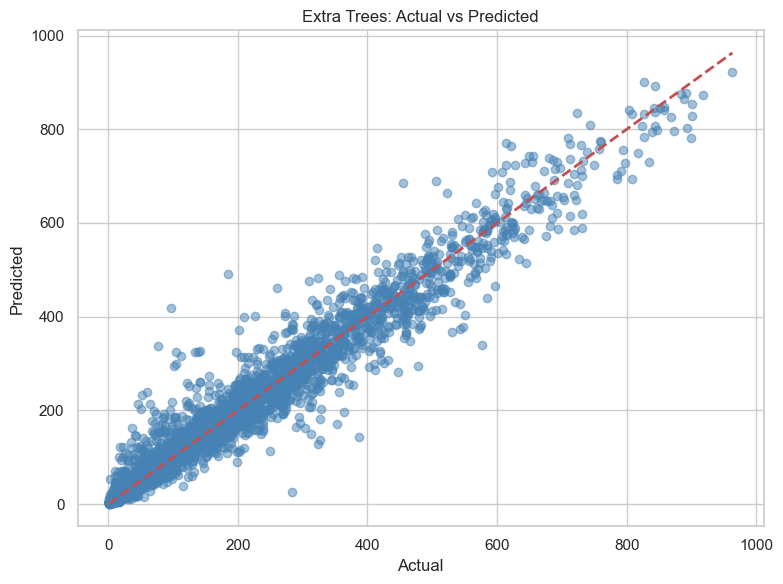

In [ ]:
# Get best model
best_model_name = results_df.iloc[0]['Model']
print(f"Best Model: {best_model_name}")

# Retrain best model for visualization
best_model = models[best_model_name]
if best_model_name == 'KNN':
    best_model.fit(X_train_sc, y_train)
    y_pred_best = best_model.predict(X_test_sc)
else:
    best_model.fit(X_train, y_train)
    y_pred_best = best_model.predict(X_test)

# Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_best, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title(f'{best_model_name}: Actual vs Predicted')
plt.tight_layout()
plt.show()

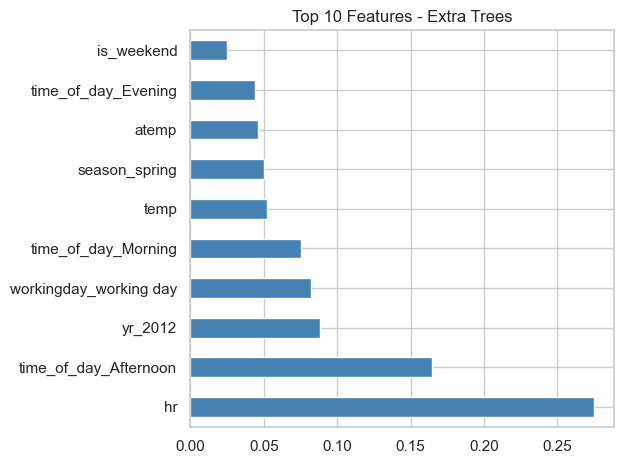

In [14]:
# Feature importance (if available)
if hasattr(best_model, 'feature_importances_'):
    importance = pd.Series(best_model.feature_importances_, index=X.columns)
    importance.nlargest(10).plot(kind='barh', color='steelblue')
    plt.title(f'Top 10 Features - {best_model_name}')
    plt.tight_layout()
    plt.show()
elif hasattr(best_model, 'coef_'):
    coef = pd.Series(best_model.coef_, index=X.columns)
    coef.abs().nlargest(10).plot(kind='barh', color='steelblue')
    plt.title(f'Top 10 Features - {best_model_name}')
    plt.tight_layout()
    plt.show()

In [ ]:
# Save the models and scaler for the Streamlit app
import joblib

# Save Extra Trees model
extra_trees = models['Extra Trees']
extra_trees.fit(X_train, y_train)
joblib.dump(extra_trees, 'model.pkl')

# Save KNN model and scaler
knn = models['KNN']
knn.fit(X_train_sc, y_train)
joblib.dump(knn, 'knn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

# Save feature columns
joblib.dump(list(X.columns), 'features.pkl')

print(f"Extra Trees model saved: model.pkl")
print(f"KNN model saved: knn_model.pkl")
print(f"Scaler saved: scaler.pkl")
print(f"Features saved: features.pkl ({len(X.columns)} features)")

## Summary

| Model | RMSE | R2 |
|-------|------|-----|
| **Best Model** | Lowest | Highest |

**Key Insights:**
- Hour of day (hr) is the most important feature
- Temperature significantly impacts bike demand
- Ensemble methods (Random Forest, Gradient Boosting, Extra Trees) typically perform best